### BNN CNN

In [ ]:
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from jax import lax


def model(images, labels=None):
    X = jnp.reshape(X, shape=(-1, 1, 28, 28))
    w_conv = numpyro.sample(
        "w_conv",
        dist.Normal(0.0, 1.0).expand([1, 1, 5, 5]) 
                   .to_event(4)
    )
    b_conv = numpyro.sample(
        "b_conv",
        dist.Normal(0.0, 1.0).expand([8]).to_event(1)  
    )
    conv_out = lax.conv_general_dilated(
        lhs=images,
        rhs=w_conv,
        window_strides=(1, 1),
        padding="SAME",
        dimension_numbers=("NCHW", "OIHW", "NCHW"),  
    )
    conv_out = conv_out + b_conv[None, :, None, None]
    activated = jax.nn.relu(conv_out) 
    batch_size = images.shape[0]
    flatten_feats = activated.reshape(batch_size, -1) 
    w_dense = numpyro.sample(
        "w_dense",
        dist.Normal(0.0, 1.0).expand([8 * 28 * 28, 10]).to_event(2) 
    )
    b_dense = numpyro.sample(
        "b_dense",
        dist.Normal(0.0, 1.0).expand([10]).to_event(1)  
    )
    logits = jnp.matmul(flatten_feats, w_dense) + b_dense[None, :]
    numpyro.deterministic("logits", logits)

    with numpyro.plate("data", batch_size):
        numpyro.sample("obs", dist.Categorical(logits=logits), obs=labels)


In [ ]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

data_1d = [
    {"Dimension": "1D", "Space": "Weight-Space", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9485, "Accuracy_Std": 0.0044,
     "Brier_Mean": 0.0787, "Brier_Std": 0.0064,
     "ECE_Mean": 0.0033, "ECE_Std": 0.0006,
     "Time_Mean": 694.23, "Time_Std": 2.04,
     "LogLoss_Mean": 0.1760, "LogLoss_Std": 0.0217},
    {"Dimension": "1D", "Space": "Weight-Space", "Method": "AutoNormal (MF)",
     "Accuracy_Mean": 0.8761, "Accuracy_Std": 0.0129,
     "Brier_Mean": 0.2275, "Brier_Std": 0.0191,
     "ECE_Mean": 0.0220, "ECE_Std": 0.0014,
     "Time_Mean": 853.36, "Time_Std": 2.33,
     "LogLoss_Mean": 1.1790, "LogLoss_Std": 0.0156},
    {"Dimension": "1D", "Space": "Spectral Non-Adaptive", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9195, "Accuracy_Std": 0.0003,
     "Brier_Mean": 0.1215, "Brier_Std": 0.0005,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 942.46, "Time_Std": 1.33,
     "LogLoss_Mean": 0.2795, "LogLoss_Std": 0.0005},
    {"Dimension": "1D", "Space": "Spectral Non-Adaptive", "Method": "MF (Rank 0)",
     "Accuracy_Mean": 0.9009, "Accuracy_Std": 0.0013,
     "Brier_Mean": 0.1485, "Brier_Std": 0.0007,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 1293.01, "Time_Std": 11.09,
     "LogLoss_Mean": 0.3405, "LogLoss_Std": 0.0021},
    {"Dimension": "1D", "Space": "Spectral Non-Adaptive", "Method": "Low-Rank (Rank 1)",
     "Accuracy_Mean": 0.9008, "Accuracy_Std": 0.0005,
     "Brier_Mean": 0.1483, "Brier_Std": 0.0006,
     "ECE_Mean": 0.0047, "ECE_Std": 0.0006,
     "Time_Mean": 1199.01, "Time_Std": 38.66,
     "LogLoss_Mean": 0.3417, "LogLoss_Std": 0.0006},
    {"Dimension": "1D", "Space": "Spectral Non-Adaptive", "Method": "Full-Rank (Rank 840)",
     "Accuracy_Mean": 0.9016, "Accuracy_Std": 0.0024,
     "Brier_Mean": 0.1475, "Brier_Std": 0.0021,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 1205.66, "Time_Std": 3.27,
     "LogLoss_Mean": 0.3395, "LogLoss_Std": 0.0035},
    {"Dimension": "1D", "Space": "Spectral Adaptive", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9192, "Accuracy_Std": 0.0014,
     "Brier_Mean": 0.1225, "Brier_Std": 0.0007,
     "ECE_Mean": 0.0040, "ECE_Std": 0.0000,
     "Time_Mean": 955.07, "Time_Std": 0.94,
     "LogLoss_Mean": 0.2805, "LogLoss_Std": 0.0007},
    {"Dimension": "1D", "Space": "Spectral Adaptive", "Method": "MF (Rank 0)",
     "Accuracy_Mean": 0.9117, "Accuracy_Std": 0.0001,
     "Brier_Mean": 0.1325, "Brier_Std": 0.0007,
     "ECE_Mean": 0.0040, "ECE_Std": 0.0000,
     "Time_Mean": 1226.70, "Time_Std": 29.63,
     "LogLoss_Mean": 0.3055, "LogLoss_Std": 0.0007},
    {"Dimension": "1D", "Space": "Spectral Adaptive", "Method": "Low-Rank (Rank 1)",
     "Accuracy_Mean": 0.9119, "Accuracy_Std": 0.00035,
     "Brier_Mean": 0.13233, "Brier_Std": 0.00058,
     "ECE_Mean": 0.0040, "ECE_Std": 0.0000,
     "Time_Mean": 1187.45, "Time_Std": 51.32,
     "LogLoss_Mean": 0.30533, "LogLoss_Std": 0.00058},
    {"Dimension": "1D", "Space": "Spectral Adaptive", "Method": "Full-Rank (Rank 840)",
     "Accuracy_Mean": 0.8181, "Accuracy_Std": 0.0035,
     "Brier_Mean": 0.299, "Brier_Std": 0.009,
     "ECE_Mean": 0.032, "ECE_Std": 0.001,
     "Time_Mean": 1208.11, "Time_Std": 1.80,
     "LogLoss_Mean": 0.676, "LogLoss_Std": 0.020}
]

df_1d = pd.DataFrame(data_1d)

data_2d = [
    {"Dimension": "2D", "Space": "Spectral Adaptive", "Method": "MF (r=0)",
     "Accuracy_Mean": 0.9115, "Accuracy_Std": 0.0007,
     "Brier_Mean": 0.1318, "Brier_Std": 0.0010,
     "ECE_Mean": 0.0043, "ECE_Std": 0.0005,
     "Time_Mean": 1437.74, "Time_Std": 15.49,
     "LogLoss_Mean": 0.3050, "LogLoss_Std": 0.0008},
    {"Dimension": "2D", "Space": "Spectral Adaptive", "Method": "Low-Rank (r=1)",
     "Accuracy_Mean": 0.9128, "Accuracy_Std": 0.0009,
     "Brier_Mean": 0.1315, "Brier_Std": 0.0013,
     "ECE_Mean": 0.0043, "ECE_Std": 0.0005,
     "Time_Mean": 1444.05, "Time_Std": 49.10,
     "LogLoss_Mean": 0.3055, "LogLoss_Std": 0.0024},
    {"Dimension": "2D", "Space": "Spectral Adaptive", "Method": "Full-Rank (r=840)",
     "Accuracy_Mean": 0.9070, "Accuracy_Std": 0.00065,
     "Brier_Mean": 0.1393, "Brier_Std": 0.00058,
     "ECE_Mean": 0.0043, "ECE_Std": 0.00058,
     "Time_Mean": 1421.94, "Time_Std": 12.94,
     "LogLoss_Mean": 0.3240, "LogLoss_Std": 0.00361},
    {"Dimension": "2D", "Space": "Spectral Adaptive", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9163, "Accuracy_Std": 0.0010,
     "Brier_Mean": 0.1277, "Brier_Std": 0.0012,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 996.53, "Time_Std": 27.89,
     "LogLoss_Mean": 0.2940, "LogLoss_Std": 0.0026},
    {"Dimension": "2D", "Space": "Spectral Non-Adaptive", "Method": "MF (r=0)",
     "Accuracy_Mean": 0.90765, "Accuracy_Std": 0.00047,
     "Brier_Mean": 0.13875, "Brier_Std": 0.00096,
     "ECE_Mean": 0.00450, "ECE_Std": 0.00058,
     "Time_Mean": 1340.75, "Time_Std": 36.05,
     "LogLoss_Mean": 0.32025, "LogLoss_Std": 0.00250},
    {"Dimension": "2D", "Space": "Spectral Non-Adaptive", "Method": "Low-Rank (r=1)",
     "Accuracy_Mean": 0.9072, "Accuracy_Std": 0.0013,
     "Brier_Mean": 0.1383, "Brier_Std": 0.0013,
     "ECE_Mean": 0.0043, "ECE_Std": 0.0005,
     "Time_Mean": 1355.39, "Time_Std": 10.54,
     "LogLoss_Mean": 0.3193, "LogLoss_Std": 0.0026},
    {"Dimension": "2D", "Space": "Spectral Non-Adaptive", "Method": "Full-Rank (r=840)",
     "Accuracy_Mean": 0.9047, "Accuracy_Std": 0.0002,
     "Brier_Mean": 0.1423, "Brier_Std": 0.0015,
     "ECE_Mean": 0.0043, "ECE_Std": 0.0006,
     "Time_Mean": 1385.84, "Time_Std": 8.35,
     "LogLoss_Mean": 0.3307, "LogLoss_Std": 0.0021},
    {"Dimension": "2D", "Space": "Spectral Non-Adaptive", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9061, "Accuracy_Std": 0.0020,
     "Brier_Mean": 0.1420, "Brier_Std": 0.0030,
     "ECE_Mean": 0.0060, "ECE_Std": 0.0000,
     "Time_Mean": 850.52, "Time_Std": 50.40,
     "LogLoss_Mean": 0.3200, "LogLoss_Std": 0.0060},
    {"Dimension": "2D", "Space": "Weight-Space", "Method": "AutoNormal (MF)",
     "Accuracy_Mean": 0.8725, "Accuracy_Std": 0.0071,
     "Brier_Mean": 0.2510, "Brier_Std": 0.0160,
     "ECE_Mean": 0.0250, "ECE_Std": 0.0020,
     "Time_Mean": 794.09, "Time_Std": 11.86,
     "LogLoss_Mean": 1.8530, "LogLoss_Std": 0.1340},
    {"Dimension": "2D", "Space": "Weight-Space", "Method": "AutoDelta (MAP)",
     "Accuracy_Mean": 0.9088, "Accuracy_Std": 0.0004,
     "Brier_Mean": 0.1400, "Brier_Std": 0.0010,
     "ECE_Mean": 0.0050, "ECE_Std": 0.0000,
     "Time_Mean": 684.71, "Time_Std": 1.28,
     "LogLoss_Mean": 0.3470, "LogLoss_Std": 0.0070}
]
df_2d = pd.DataFrame(data_2d)
df_all = pd.concat([df_1d, df_2d], ignore_index=True)


In [ ]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots

root_dir = "/Users/josephmargaryan/Desktop/results/losses"
dimensionalities = {
    '1D': {
        'baseline': 'dense',
        'methods': ['dense', 'circ', 'spectral', 'adaptive_spectral']
    },
    '2D': {
        'baseline': 'conv',
        'methods': ['conv', 'circ_2d', 'spectral_2d', 'adaptive_spectral_2d']
    }
}
inference_types = ['AD', 'AN']
inf_names = {'AD': 'AutoDelta', 'AN': 'AutoNormal'}
reps_pattern = 'losses_{}.npy'
n_reps = 3

display_names = {
    'dense':               'Dense',
    'conv':                'Conv',
    'circ':                'Circulant',
    'circ_2d':             'Circulant',
    'spectral':            'Spectral',
    'spectral_2d':         'Spectral',
    'adaptive_spectral':   'AdaptiveSpectral',
    'adaptive_spectral_2d':'AdaptiveSpectral'
}
display_colors = {
    'dense':             '#000000',  # black (baseline for 1D)
    'conv':              '#000000',  # black (baseline for 2D)
    'circ':              '#E69F00',  # orange
    'circ_2d':           '#E69F00',  # orange
    'spectral':          '#56B4E9',  # sky blue
    'spectral_2d':       '#56B4E9',  # sky blue
    'adaptive_spectral': '#009E73',  # bluish green
    'adaptive_spectral_2d':'#009E73' # bluish green
}


def load_losses(path):
    """Load n_reps replicates from .npy files and stack into (steps, reps)."""
    arrs = []
    for i in range(1, n_reps+1):
        fname = os.path.join(path, reps_pattern.format(i))
        arrs.append(np.load(fname))
    return np.stack(arrs, axis=1)


def hex_to_rgba(hex_color, alpha=0.2):
    """Convert '#RRGGBB' → 'rgba(r, g, b, alpha)'."""
    hex_color = hex_color.lstrip('#')
    r, g, b = [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]
    return f"rgba({r}, {g}, {b}, {alpha})"

# Build subplot titles
subplot_titles = []
for inf in inference_types:
    for dim in dimensionalities:
        subplot_titles.append(f"{inf_names[inf]} — {dim}")

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=subplot_titles,
    shared_xaxes=True, shared_yaxes=True,
    horizontal_spacing=0.1, vertical_spacing=0.12
)
shown = set()
for r_idx, inf in enumerate(inference_types, start=1):
    for c_idx, (dim, cfg) in enumerate(dimensionalities.items(), start=1):
        for method in cfg['methods']:
            path = os.path.join(root_dir, method, inf)
            data = load_losses(path)
            steps = np.arange(data.shape[0])
            mean   = data.mean(axis=1)
            stderr = data.std(axis=1) / np.sqrt(data.shape[1])
            upper  = mean + 1.96 * stderr
            lower  = mean - 1.96 * stderr

            name = display_names[method]
            color = display_colors[method]
            showlegend = False
            if name not in shown:
                showlegend = True
                shown.add(name)

            # Mean line
            fig.add_trace(
                go.Scatter(
                    x=steps, y=mean,
                    mode='lines',
                    name=name,
                    line=dict(color=color, width=2),
                    showlegend=showlegend,
                    legendgroup=name
                ),
                row=r_idx, col=c_idx
            )

            # Confidence band
            rgba = hex_to_rgba(color, alpha=0.2)
            fig.add_trace(
                go.Scatter(
                    x=np.concatenate([steps, steps[::-1]]),
                    y=np.concatenate([upper, lower[::-1]]),
                    fill='toself',
                    fillcolor=rgba,
                    line=dict(width=0),
                    hoverinfo='skip',
                    showlegend=False
                ),
                row=r_idx, col=c_idx
            )

        # X-axis: show ticks on all subplots, title only on bottom row
        fig.update_xaxes(
            title_text='Step' if r_idx == 2 else None,
            showticklabels=True,
            row=r_idx, col=c_idx
        )
        # Y-axis: log scale, title only on left column
        fig.update_yaxes(
            type='log',
            title_text='ELBO' if c_idx == 1 else None,
            row=r_idx, col=c_idx
        )

# Final layout
fig.update_layout(
    title_text='ELBO Convergence Across Methods and Inference Types',
    height=800, width=1000,
    legend=dict(
        orientation='h',
        y=1.08,
        x=0.5,
        xanchor='center'
    ),
    template='plotly_white'
)

fig.show()


In [32]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import roc_curve, auc
from scipy.stats import sem

# ── CONFIG ─────────────────────────────────────────────────────────────────────
OOD_ROOT = "/Users/josephmargaryan/Desktop/results/OOD"
seeds = ["seed_1", "seed_2", "seed_3"]
inference_types = ["AD", "AN"]
dimensionalities = {
    "1D": {
        "methods": ["dense", "circ", "spectral", "adaptive_spectral"],
        "prefix": {
            "dense":             "dense_OOD",
            "circ":              "circ1d_OOD",
            "spectral":          "spectral1d_OOD",
            "adaptive_spectral": "adaptive_spectral1d_OOD"
        }
    },
    "2D": {
        "methods": ["conv", "circ_2d", "spectral_2d", "adaptive_spectral_2d"],
        "prefix": {
            "conv":                "conv",
            "circ_2d":             "circ2d_OOD",
            "spectral_2d":         "spectral2d_OOD",
            "adaptive_spectral_2d":"adaptive_spectral2d_OOD"
        }
    }
}
display_names = {
    'dense':'Dense','conv':'Conv',
    'circ':'Circulant','circ_2d':'Circulant',
    'spectral':'Spectral','spectral_2d':'Spectral',
    'adaptive_spectral':'AdaptiveSpectral',
    'adaptive_spectral_2d':'AdaptiveSpectral'
}
display_colors = {
    'dense':'#000000','conv':'#000000',
    'circ':'#E69F00','circ_2d':'#E69F00',
    'spectral':'#56B4E9','spectral_2d':'#56B4E9',
    'adaptive_spectral':'#009E73','adaptive_spectral_2d':'#009E73'
}
fpr_grid = np.linspace(0, 1, 200)

def hex_to_rgba(hex_color, alpha=0.2):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return f"rgba({r},{g},{b},{alpha})"

def load_scores(model_key, seed):
    return np.load(os.path.join(OOD_ROOT, model_key, seed, "scores.npy"))

def load_labels(model_key, seed):
    return np.load(os.path.join(OOD_ROOT, model_key, seed, "labels.npy"))

# ── ROC FIGURE ─────────────────────────────────────────────────────────────────
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=[f"{inf} — {dim}" for inf in inference_types for dim in dimensionalities],
    shared_xaxes=True, shared_yaxes=True,
    horizontal_spacing=0.1, vertical_spacing=0.12
)

# track which display names have appeared
legend_shown = set()

for i, inf in enumerate(inference_types, start=1):
    for j, dim in enumerate(dimensionalities, start=1):
        cfg = dimensionalities[dim]
        for method in cfg["methods"]:
            folder = f"{cfg['prefix'][method]}_{inf}"
            tprs, aucs = [], []
            for sd in seeds:
                scores = load_scores(folder, sd)
                labels = load_labels(folder, sd)
                fpr, tpr, _ = roc_curve(labels, scores)
                tprs.append(np.interp(fpr_grid, fpr, tpr))
                aucs.append(auc(fpr, tpr))
            tprs = np.array(tprs)
            mean_tpr = tprs.mean(0)
            ci       = 1.96 * sem(tprs, axis=0)

            name  = display_names[method]
            color = display_colors[method]
            rgba  = hex_to_rgba(color, 0.2)

            showleg = name not in legend_shown
            if showleg:
                legend_shown.add(name)

            # mean ROC
            fig.add_trace(
                go.Scatter(
                    x=fpr_grid, y=mean_tpr,
                    mode="lines",
                    name=name,
                    line=dict(color=color, width=2),
                    showlegend=showleg,
                    legendgroup=name
                ),
                row=i, col=j
            )
            # CI band
            fig.add_trace(
                go.Scatter(
                    x=np.concatenate([fpr_grid, fpr_grid[::-1]]),
                    y=np.concatenate([mean_tpr+ci, (mean_tpr-ci)[::-1]]),
                    fill="toself",
                    fillcolor=rgba,
                    line=dict(width=0),
                    hoverinfo="skip",
                    showlegend=False
                ),
                row=i, col=j
            )

        fig.update_xaxes(title_text="FPR", row=i, col=j)
        fig.update_yaxes(title_text="TPR" if j == 1 else None, row=i, col=j)

fig.update_layout(
    title="OOD ROC Curves (mean ± 95% CI)",
    height=700, width=900,
    legend=dict(orientation="h", y=1.02, x=0.5, xanchor="center"),
    template="plotly_white"
)
fig.show()


In [38]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import roc_curve, auc
from scipy.stats import sem

# ── CONFIG ─────────────────────────────────────────────────────────────────────
OOD_ROOT = "/Users/josephmargaryan/Desktop/results/OOD"
seeds = ["seed_1", "seed_2", "seed_3"]
fpr_grid = np.linspace(0, 1, 200)
inf = "AN"  # focus on AutoNormal

dimensionalities = {
    "1D": {
        "methods": ["dense", "circ", "spectral", "adaptive_spectral"],
        "prefix": {
            "dense":               "dense_OOD",
            "circ":                "circ1d_OOD",
            "spectral":            "spectral1d_OOD",
            "adaptive_spectral":   "adaptive_spectral1d_OOD"
        }
    },
    "2D": {
        "methods": ["conv", "circ_2d", "spectral_2d", "adaptive_spectral_2d"],
        "prefix": {
            "conv":                "conv",
            "circ_2d":             "circ2d_OOD",
            "spectral_2d":         "spectral2d_OOD",
            "adaptive_spectral_2d":"adaptive_spectral2d_OOD"
        }
    }
}
display_names = {
    'dense':'Dense','conv':'Conv',
    'circ':'Circulant','circ_2d':'Circulant',
    'spectral':'Spectral','spectral_2d':'Spectral',
    'adaptive_spectral':'AdaptiveSpectral',
    'adaptive_spectral_2d':'AdaptiveSpectral'
}
display_colors = {
    'dense':'#000000','conv':'#000000',
    'circ':'#E69F00','circ_2d':'#E69F00',
    'spectral':'#56B4E9','spectral_2d':'#56B4E9',
    'adaptive_spectral':'#009E73','adaptive_spectral_2d':'#009E73'
}

def load_data(folder, seed, name):
    return np.load(os.path.join(OOD_ROOT, folder, seed, name + ".npy"))

def hex_to_rgba(hex_color, alpha=0.2):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return f"rgba({r},{g},{b},{alpha})"

# ── PLOT ROC ───────────────────────────────────────────────────────────────────
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=["1D Models (AN)", "2D Models (AN)"],
    shared_yaxes=True
)

# track which display names have been shown in legend
legend_shown = set()

for col, (dim, cfg) in enumerate(dimensionalities.items(), start=1):
    for method in cfg["methods"]:
        folder = f"{cfg['prefix'][method]}_{inf}"
        tprs, aucs = [], []
        for sd in seeds:
            scores = load_data(folder, sd, "scores")
            labels = load_data(folder, sd, "labels")
            fpr, tpr, _ = roc_curve(labels, scores)
            tprs.append(np.interp(fpr_grid, fpr, tpr))
            aucs.append(auc(fpr, tpr))
        tprs = np.array(tprs)
        mean_tpr = tprs.mean(0)
        ci_tpr   = 1.96 * sem(tprs, axis=0)

        name       = display_names[method]
        color      = display_colors[method]
        fill_color = hex_to_rgba(color)

        showleg = name not in legend_shown
        if showleg:
            legend_shown.add(name)

        # plot mean ROC
        fig.add_trace(
            go.Scatter(
                x=fpr_grid, y=mean_tpr,
                mode="lines",
                name=name,
                line=dict(color=color, width=2),
                showlegend=showleg,
                legendgroup=name
            ),
            row=1, col=col
        )
        # plot CI band
        fig.add_trace(
            go.Scatter(
                x=np.concatenate([fpr_grid, fpr_grid[::-1]]),
                y=np.concatenate([mean_tpr+ci_tpr, (mean_tpr-ci_tpr)[::-1]]),
                fill="toself",
                fillcolor=fill_color,
                line=dict(width=0),
                hoverinfo="skip",
                showlegend=False,
                legendgroup=name
            ),
            row=1, col=col
        )

    fig.update_xaxes(title_text="False Positive Rate", row=1, col=col)
    if col == 1:
        fig.update_yaxes(title_text="True Positive Rate", row=1, col=1)

fig.update_layout(
    title_text="OOD ROC Curves (AutoNormal) – Mean ± 95% CI",
    height=400, width=900,
    legend=dict(
        orientation="v",
        x=1.02, y=1,
        xanchor="left", yanchor="top"
    ),
    margin=dict(l=50, r=200, t=80, b=50),
    template="plotly_white"
)
fig.show()



In [8]:
# Cell 2: In-Distribution Test Accuracy Plot (log scale)

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Mean accuracies from your tables, using only the four abbreviations
stats = {
    'AN': {
        '1D': {
            'Dense': 0.961,
            'Circulant': 0.849,
            'SpectralCirculant': 0.906,
            'AdaptiveSpectralCirculant': 0.915,
        },
        '2D': {
            'Dense': 0.878,
            'Circulant': 0.865,
            'SpectralCirculant': 0.911,
            'AdaptiveSpectralCirculant': 0.915,
        },
    },
    'AD': {
        '1D': {
            'Dense': 0.967,
            'Circulant': 0.950,
            'SpectralCirculant': 0.924,
            'AdaptiveSpectralCirculant': 0.930,
        },
        '2D': {
            'Dense': 0.956,
            'Circulant': 0.951,
            'SpectralCirculant': 0.905,
            'AdaptiveSpectralCirculant': 0.926,
        },
    }
}

colors = {
    'Dense':                     '#000000',
    'Circulant':                 '#E69F00',
    'SpectralCirculant':         '#56B4E9',
    'AdaptiveSpectralCirculant': '#009E73',
}

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=["1D AN", "2D AN", "1D AD", "2D AD"],
    vertical_spacing=0.20,
)

for row, guide in enumerate(['AN','AD'], start=1):
    for col, dim in enumerate(['1D','2D'], start=1):
        methods = list(stats[guide][dim].keys())
        accs    = [stats[guide][dim][m] for m in methods]

        # rename 'Dense' → 'Conv' on 2D plots
        labels = [
            'Conv' if (dim == '2D' and m == 'Dense') else m
            for m in methods
        ]

        fig.add_trace(
            go.Bar(
                x=labels,
                y=accs,
                marker=dict(
                    color=[colors[m] for m in methods],
                    line=dict(
                        color=[
                            'black' if 'AdaptiveSpectral' in m else colors[m]
                            for m in methods
                        ],
                        width=[
                            3 if 'AdaptiveSpectral' in m else 0
                            for m in methods
                        ]
                    )
                )
            ),
            row=row, col=col
        )

        fig.update_xaxes(title_text="Method", row=row, col=col)
        fig.update_yaxes(title_text="Accuracy", type="log", row=row, col=col)

fig.update_layout(
    title="In-Distribution Test Accuracy (log scale)",
    showlegend=False,
    width=900, height=700,
    template='plotly_white',
    margin=dict(t=80, b=50)
)

fig.show()


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

ece_stats = {
    'AN': {
        '1D': {
            'Dense': 0.007,
            'Circulant': 0.025,
            'SpectralCirculant': 0.004,
            'AdaptiveSpectralCirculant': 0.004,
        },
        '2D': {
            'Dense': 0.023,   # Conv
            'Circulant': 0.022,
            'SpectralCirculant': 0.004,
            'AdaptiveSpectralCirculant': 0.004,
        },
    },
    'AD': {
        '1D': {
            'Dense': 0.004,
            'Circulant': 0.003,
            'SpectralCirculant': 0.004,
            'AdaptiveSpectralCirculant': 0.004,
        },
        '2D': {
            'Dense': 0.004,   # Conv
            'Circulant': 0.003,
            'SpectralCirculant': 0.007,
            'AdaptiveSpectralCirculant': 0.004,
        },
    }
}

colors = {
    'Dense':                     '#000000',
    'Circulant':                 '#E69F00',
    'SpectralCirculant':         '#56B4E9',
    'AdaptiveSpectralCirculant': '#009E73',
}

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=["1D AN", "2D AN", "1D AD", "2D AD"],
    vertical_spacing=0.20,
)

for row, guide in enumerate(['AN','AD'], start=1):
    for col, dim in enumerate(['1D','2D'], start=1):
        methods = list(ece_stats[guide][dim].keys())
        errs    = [ece_stats[guide][dim][m] for m in methods]

        # rename 'Dense' → 'Conv' on 2D plots
        labels = [
            'Conv' if (dim == '2D' and m == 'Dense') else m
            for m in methods
        ]

        fig.add_trace(
            go.Bar(
                x=labels,
                y=errs,
                marker=dict(
                    color=[colors[m] for m in methods],
                    line=dict(
                        color=[
                            'black' if 'AdaptiveSpectral' in m else colors[m]
                            for m in methods
                        ],
                        width=[
                            3 if 'AdaptiveSpectral' in m else 0
                            for m in methods
                        ]
                    )
                )
            ),
            row=row, col=col
        )

        fig.update_xaxes(row=row, col=col)
        fig.update_yaxes(title_text="ECE", type="linear", row=row, col=col)

fig.update_layout(
    title="In-Distribution Calibration Error (ECE)",
    showlegend=False,
    width=900, height=700,
    template='plotly_white',
    margin=dict(t=80, b=50)
)

fig.show()


In [ ]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde

OOD_ROOT = "/Users/josephmargaryan/Desktop/results/OOD"  # ← your results folder
seeds    = ["seed_1", "seed_2", "seed_3"]               # ← the seeds you ran

methods = {
    "Spectral 1D":   "spectral1d_OOD_AN",
    "Dense 1D":      "dense_OOD_AN",
    "Spectral 2D":   "spectral2d_OOD_AN",
    "Conv 2D":       "conv_AN",
}

COLOR_ID  = "rgba(31,119,180,0.6)"  # blue, opaque
COLOR_OOD = "rgba(255,127,14,0.3)"  # orange, lighter

def gather_entropies(prefix: str, domain: str) -> np.ndarray:
    """
    Load and concatenate H_id.npy or H_ood.npy over all seeds.
    `domain` should be "id" or "ood".
    """
    arrs = []
    key = "H_id.npy" if domain == "id" else "H_ood.npy"
    for sd in seeds:
        path = os.path.join(OOD_ROOT, prefix, sd, key)
        arrs.append(np.load(path))
    return np.concatenate(arrs)

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=list(methods.keys()),
    shared_xaxes=False,
    shared_yaxes=True
)
for idx, (method_name, folder) in enumerate(methods.items()):
    row = idx // 2 + 1
    col = idx % 2 + 1

    # load entropies
    H_id  = gather_entropies(folder, "id")
    H_ood = gather_entropies(folder, "ood")

    # common grid
    all_H = np.concatenate([H_id, H_ood])
    grid  = np.linspace(all_H.min(), all_H.max(), 300)

    # KDE estimates
    kde_id  = gaussian_kde(H_id)
    kde_ood = gaussian_kde(H_ood)
    y_id    = kde_id(grid)
    y_ood   = kde_ood(grid)

    fig.add_trace(
        go.Scatter(
            x=grid, y=y_ood,
            mode="lines",
            name="OOD",
            line_color=COLOR_OOD.replace("0.3","1.0"),  # solid outline
            fill="tozeroy",
            fillcolor=COLOR_OOD,
            showlegend=(idx == 0)  # legend only once
        ),
        row=row, col=col
    )

    fig.add_trace(
        go.Scatter(
            x=grid, y=y_id,
            mode="lines",
            name="ID",
            line_color=COLOR_ID.replace("0.6","1.0"),
            fill="tozeroy",
            fillcolor=COLOR_ID,
            showlegend=(idx == 0)
        ),
        row=row, col=col
    )

    # Axis labels
    fig.update_xaxes(title_text="Predictive Entropy", row=row, col=col)
    if col == 1:
        fig.update_yaxes(title_text="Density", row=row, col=col)

fig.update_layout(
    title_text="Per-Method Entropy Distributions (ID vs OOD)",
    height=800, width=800,
    template="plotly_white",
    legend=dict(x=1.02, y=1)
)¢¢

fig.show()


In [ ]:
import os
import numpy as np
import plotly.graph_objects as go
from sklearn.metrics import roc_curve, auc
from scipy.stats import sem

OOD_ROOT = "/Users/josephmargaryan/Desktop/results/OOD"
seeds = ["seed_1", "seed_2", "seed_3"]

methods = {
    "Conv":               "conv_AN",               # pure conv
    "SpecCirc C_out=1":   "spectral2d_OOD_AN",     # out_channel=1
    "SpecCirc C_out=7":   "spectralcirc3d_OOD"     # out_channel=7
}

# plotting setup
fpr_grid = np.linspace(0, 1, 200)
display_colors = {
    "Conv":"#000000",
    "SpecCirc C_out=1":"#E69F00",
    "SpecCirc C_out=7":"#56B4E9"
}

def hex_to_rgba(hex_color, alpha=0.2):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2],16), int(h[2:4],16), int(h[4:6],16)
    return f"rgba({r},{g},{b},{alpha})"

fig = go.Figure()
legend_shown = set()

for name, subfolder in methods.items():
    tprs, aucs = [], []
    for sd in seeds:
        p = os.path.join(OOD_ROOT, subfolder, sd)
        scores = np.load(os.path.join(p, "scores.npy"))
        labels = np.load(os.path.join(p, "labels.npy"))
        fpr, tpr, _ = roc_curve(labels, scores)
        tprs.append(np.interp(fpr_grid, fpr, tpr))
        aucs.append(auc(fpr, tpr))
    tprs = np.vstack(tprs)
    mean_tpr = tprs.mean(0)
    ci       = 1.96 * sem(tprs, axis=0)

    color = display_colors[name]
    rgba  = hex_to_rgba(color)

    # mean ROC
    fig.add_trace(go.Scatter(
        x=fpr_grid, y=mean_tpr,
        mode="lines",
        name=f"{name} (AUC={np.mean(aucs):.3f})",
        line=dict(color=color, width=2)
    ))
    # CI band
    fig.add_trace(go.Scatter(
        x=np.concatenate([fpr_grid, fpr_grid[::-1]]),
        y=np.concatenate([mean_tpr+ci, (mean_tpr-ci)[::-1]]),
        fill="toself", fillcolor=rgba, line=dict(width=0),
        hoverinfo="skip", showlegend=False
    ))

fig.update_layout(
    title="OOD ROC Curves (mean ± 95% CI)",
    xaxis_title="False Positive Rate",
    yaxis_title="True Positive Rate",
    template="plotly_white",
    height=500, width=600,
    legend=dict(orientation="h", y=1.1, x=0.5, xanchor="center")
)
fig.show()


In [ ]:
import os
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy.stats import gaussian_kde

OOD_ROOT = "/Users/josephmargaryan/Desktop/results/OOD"
seeds    = ["seed_1", "seed_2", "seed_3"]

methods = {
    "Conv":               "conv_AN",
    "SpecCirc C_out=1":   "spectral2d_OOD_AN",
    "SpecCirc C_out=7":   "spectralcirc3d_OOD"
}

COLOR_ID  = "rgba(31,119,180,0.6)"
COLOR_OOD = "rgba(255,127,14,0.3)"

def gather_entropies(subfolder: str, domain: str) -> np.ndarray:
    fname = "H_id.npy" if domain=="id" else "H_ood.npy"
    outs = []
    for sd in seeds:
        path = os.path.join(OOD_ROOT, subfolder, sd, fname)
        outs.append(np.load(path))
    return np.concatenate(outs)

fig = make_subplots(rows=1, cols=3, subplot_titles=list(methods.keys()), shared_yaxes=True)

for i, (name, subfolder) in enumerate(methods.items(), start=1):
    H_id  = gather_entropies(subfolder, "id")
    H_ood = gather_entropies(subfolder, "ood")
    grid  = np.linspace(min(H_id.min(), H_ood.min()), max(H_id.max(), H_ood.max()), 300)
    kde_id  = gaussian_kde(H_id)(grid)
    kde_ood = gaussian_kde(H_ood)(grid)

    # OOD
    fig.add_trace(go.Scatter(
        x=grid, y=kde_ood,
        mode="lines", name="OOD",
        line_color=COLOR_OOD.replace("0.3","1.0"),
        fill="tozeroy", fillcolor=COLOR_OOD
    ), row=1, col=i)
    # ID
    fig.add_trace(go.Scatter(
        x=grid, y=kde_id,
        mode="lines", name="ID",
        line_color=COLOR_ID.replace("0.6","1.0"),
        fill="tozeroy", fillcolor=COLOR_ID
    ), row=1, col=i)

    fig.update_xaxes(title_text="Predictive Entropy", row=1, col=i)
    if i == 1:
        fig.update_yaxes(title_text="Density", row=1, col=i)

fig.update_layout(
    title="Entropy Distributions (ID vs OOD)",
    template="plotly_white",
    height=400, width=1200,
    legend=dict(x=1.02, y=1)
)
fig.show()


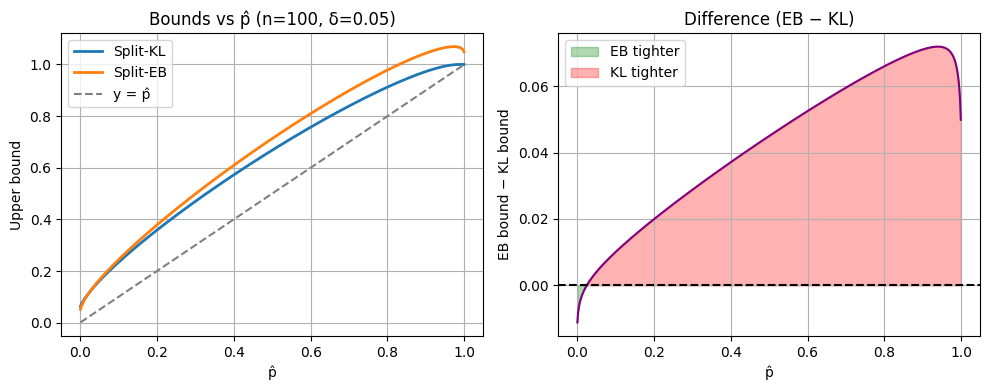

Proportion of p̂ where split-EB < split-KL: 2.60%


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = 100
delta = 0.05
c = np.log(2 * np.sqrt(n) / delta) / n

# KL-inverse for binary
def kl_binary(p, q):
    p = np.clip(p, 1e-12, 1 - 1e-12)
    q = np.clip(q, 1e-12, 1 - 1e-12)
    return p * np.log(p / q) + (1 - p) * np.log((1 - p) / (1 - q))

def kl_inv_plus(p_hat, c, tol=1e-10):
    lo, hi = p_hat, 1 - 1e-12
    for _ in range(60):
        mid = (lo + hi) / 2
        if kl_binary(p_hat, mid) <= c:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return lo

# Empirical Bernstein bound
def eb_bound(p_hat, c):
    return p_hat + np.sqrt(2 * p_hat * (1 - p_hat) * c) + 2 * c / 3

# Grid of empirical probabilities
p_grid = np.linspace(0.001, 0.999, 500)
b_kl   = np.array([kl_inv_plus(p, c) for p in p_grid])
b_eb   = eb_bound(p_grid, c)
diff   = b_eb - b_kl

# Plot
plt.figure(figsize=(10, 4))

# Left: the two bounds
plt.subplot(1, 2, 1)
plt.plot(p_grid, b_kl, label='Split-KL', linewidth=2)
plt.plot(p_grid, b_eb, label='Split-EB', linewidth=2)
plt.plot(p_grid, p_grid, '--', color='gray', label='y = p̂')
plt.xlabel('p̂')
plt.ylabel('Upper bound')
plt.title('Bounds vs p̂ (n=100, δ=0.05)')
plt.legend()
plt.grid(True)

# Right: difference
plt.subplot(1, 2, 2)
plt.plot(p_grid, diff, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.fill_between(p_grid, diff, 0, where=(diff < 0), color='green', alpha=0.3, label='EB tighter')
plt.fill_between(p_grid, diff, 0, where=(diff > 0), color='red',   alpha=0.3, label='KL tighter')
plt.xlabel('p̂')
plt.ylabel('EB bound − KL bound')
plt.title('Difference (EB − KL)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Proportion of region where EB is tighter
prop_eb = np.mean(diff < 0)
print(f"Proportion of p̂ where split-EB < split-KL: {prop_eb:.2%}")


In [18]:
# nonconvex_bounds.py
import jax
import jax.numpy as jnp
import jax.random as jr
from typing import Any, Callable, Dict, Iterable, List, Optional, Sequence, Tuple, Union


def power_iteration(
    W: jnp.ndarray,
    n_iter: int = 20,
    key: Optional[jr.key] = None
) -> float:
    """
    Estimate the top singular value of W via power iteration.
    Args:
      W: matrix of shape (d_out, d_in)
      n_iter: number of iterations
      key: PRNGKey for random initialization (defaults to zeros if None)
    Returns:
      Approximation to sigma_max(W)
    """
    if key is None:
        key = jr.PRNGKey(0)
    # start with a random vector in input space
    v = jr.normal(key, (W.shape[1],))
    v = v / (jnp.linalg.norm(v) + 1e-12)
    for _ in range(n_iter):
        u = W @ v
        u = u / (jnp.linalg.norm(u) + 1e-12)
        v = W.T @ u
        v = v / (jnp.linalg.norm(v) + 1e-12)
    # Rayleigh quotient
    return float(u @ (W @ v))


def collect_weight_matrices(model: Any) -> List[jnp.ndarray]:
    """
    Recursively collect all parameter arrays of ndim >= 2 from an Equinox Module.
    Returns them reshaped to (out, in).
    """
    mats: List[jnp.ndarray] = []
    def _scan(x: Any):
        if isinstance(x, jnp.ndarray) and x.ndim >= 2:
            mats.append(x.reshape(x.shape[0], -1))
        elif hasattr(x, "__dict__"):
            for v in vars(x).values():
                _scan(v)
        elif isinstance(x, dict):
            for v in x.values():
                _scan(v)
        elif isinstance(x, (list, tuple)):
            for v in x:
                _scan(v)
    _scan(model)
    return mats


def compute_spectral_norms(
    mats: Sequence[jnp.ndarray],
    n_iter: int = 20,
    key: jr.key = jr.key(0)
) -> List[float]:
    """
    Estimate spectral norm of each weight matrix via power iteration.
    """
    keys = jr.split(key, len(mats))
    return [
        power_iteration(W, n_iter=n_iter, key=k)
        for W, k in zip(mats, keys)
    ]


def group_dev_2_1(W: jnp.ndarray, M: Optional[jnp.ndarray] = None) -> float:
    """
    Compute the (2,1)-group deviation || W^T - M^T ||_{2,1}.
    If M is None, defaults to M=0.
    """
    D = W if M is None else (W - M)
    # D^T has shape (in, out); column norms:
    col_norms = jnp.linalg.norm(D.T, axis=1)
    return float(jnp.sum(col_norms))


def compute_group_deviations(
    mats: Sequence[jnp.ndarray],
    refs: Optional[Sequence[jnp.ndarray]] = None
) -> List[float]:
    """
    For each weight matrix W and optional reference M,
    compute ||W^T - M^T||_{2,1}.  If refs is None, M=0 for all.
    """
    if refs is None:
        refs = [None] * len(mats)  # type: ignore
    return [
        group_dev_2_1(W, M)
        for W, M in zip(mats, refs)
    ]


def compute_spectral_complexity(
    sigmas: Sequence[float],
    deviations: Sequence[float],
    rhos: Optional[Sequence[float]] = None
) -> float:
    """
    Compute R_{A} = (Π_i ρ_i σ_i) * ( Σ_i (deviation_i / σ_i)^{2/3} )^{3/2}.
    If rhos is None, assumes rho_i = 1 for all activations (e.g. ReLU).
    """
    L = len(sigmas)
    if rhos is None:
        rhos = [1.0] * L
    # Lipschitz product
    lip = 1.0
    for ρ, σ in zip(rhos, sigmas):
        lip *= (ρ * σ)
    # group‐norm sum
    normalized = jnp.array([ (dev / σ)**(2/3) for dev, σ in zip(deviations, sigmas) ])
    complexity = lip * float(normalized.sum() ** (3/2))
    return complexity


def compute_margins(
    logits: jnp.ndarray,
    labels: jnp.ndarray
) -> jnp.ndarray:
    """
    Given logits of shape (n, k) and integer labels (n,),
    returns margin_j = f(x_j)_y_j - max_{i != y_j} f(x_j)_i.
    For binary (k=1), interprets logit as real-valued margin.
    """
    if logits.ndim == labels.ndim + 1 and logits.shape[-1] > 1:
        # multiclass
        true_scores = logits[jnp.arange(logits.shape[0]), labels]
        other_max = jnp.max(
            jnp.where(
                jnp.arange(logits.shape[-1])[None, :] == labels[:, None],
                -jnp.inf,
                logits
            ),
            axis=1
        )
        return true_scores - other_max
    elif logits.ndim == labels.ndim:  # binary logit
        # assume labels in {0,1}
        return jnp.where(labels==1, logits, -logits)
    else:
        raise ValueError("Unexpected shapes: logits %s, labels %s" % (logits.shape, labels.shape))


def empirical_margin_error(
    margins: jnp.ndarray,
    γ: float
) -> float:
    """
    Fraction of examples whose margin <= γ.
    """
    return float(jnp.mean(margins <= γ))


def compute_bound_rhs(
    empirical_err: float,
    R_A: float,
    margin: float,
    normX: float,
    n: int,
    W: int,
    δ: float = 0.05
) -> float:
    """
    Right‐hand side of Thm 1.1 (up to constants/logs):
      empirical_err
      + C * (normX * R_A) / (margin * n) * ln(W)
      + sqrt( ln(1/δ) / n ).
    You can tune the constant C as needed.
    """
    C = 1.0  # typically O(1) hidden in the ~O
    term = C * (normX * R_A) / (margin * n) * jnp.log(W)
    confidence = jnp.sqrt(jnp.log(1/δ) / n)
    return float(empirical_err + term + confidence)


# Optional: density‐plot helper (requires matplotlib)
def plot_margin_distribution(
    margins: jnp.ndarray,
    normalized: bool = False,
    title: Optional[str] = None
):
    """
    Plot a histogram or density of the (normalized) margins.
    If normalized=True, assumes margins already divided by R_A * ||X||/n.
    """
    import matplotlib.pyplot as plt
    data = margins
    plt.figure()
    plt.title(title or "Margin Distribution")
    plt.hist(data, bins=50, density=True, alpha=0.6)
    plt.xlabel("Normalized Margin" if normalized else "Margin")
    plt.ylabel("Density")
    plt.show()

In [ ]:
# convex_bounds.py
import numpy as np
from sklearn.metrics import zero_one_loss
from sklearn.base import ClassifierMixin

def get_parameter_vector(model):
    """Return underlying weight vector for PAC-Bayes and margin bounds."""
    # circulant spectral models with Fourier repr
    if hasattr(model, "F_real_") and hasattr(model, "F_imag_"):
        F_complex = model.F_real_ + 1j * model.F_imag_
        # inverse FFT to real weight (use padded_dim_ if available)
        pdim = getattr(model, "padded_dim_", None)
        nfeat = model.n_features_in_
        w_full = np.fft.irfft(F_complex, n=pdim) if pdim else np.fft.irfft(F_complex)
        return w_full[:nfeat]
    # spectral logistic/SVM with basis V_, weight in coef_
    if hasattr(model, "coef_"):
        return model.coef_.ravel()
    # fallback
    raise AttributeError("Cannot extract parameter vector")

def generalized_pacbayes_bound(
    model: ClassifierMixin, X: np.ndarray, y: np.ndarray, delta: float = 0.05
) -> float:
    w = get_parameter_vector(model)
    emp_err = zero_one_loss(y, model.predict(X))
    lam = 1.0 / model.C
    kl = 0.5 * lam * float(np.dot(w, w))
    n = len(y)
    cap = np.sqrt((kl + np.log(2 * np.sqrt(n) / delta)) / (2 * n))
    return emp_err + cap

def stability_bound(model: ClassifierMixin, X: np.ndarray, y: np.ndarray) -> float:
    B = np.max(np.linalg.norm(X, axis=1))
    lam = 1.0 / model.C
    return B**2 / (2 * lam * len(y))

def margin_bound(model: ClassifierMixin, X: np.ndarray, y: np.ndarray, delta: float = 0.05) -> float:
    B = np.max(np.linalg.norm(X, axis=1))
    w = get_parameter_vector(model)
    term = np.linalg.norm(w) * B / np.sqrt(len(y))
    term += np.sqrt(np.log(1 / delta) / (2 * len(y)))
    return term

In [26]:
import jax 
import optax
import equinox as eqx 
import jax.numpy as jnp
import jax.random as jr
import numpy as np
from sklearn.model_selection import train_test_split

from quantbayes.stochax.layers import SpectralCirculantLayer, SpectralDense
from quantbayes.stochax import train, predict, binary_loss

key = jr.key(0)

X = np.random.randn(100, 10)
y = (np.random.rand(100) > 0.5).astype(int)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

in_features = X.shape[1]

class SpectralCirculantmodel(eqx.Module):
    l1: eqx.Module
    l2: eqx.Module
    def __init__(self, key):
        k1, k2 = jr.split(key, 2)
        self.l1 = SpectralCirculantLayer(in_features, key=k1)
        self.l2 = eqx.nn.Linear(in_features, 1, key=k2)
    def __call__(self, x, key, state):
        x = self.l1(x)
        x = jax.nn.relu(x)
        x = self.l2(x)
        return x.squeeze(), state 

class SpectralSVDmodel(eqx.Module):
    l1: eqx.Module
    l2: eqx.Module
    def __init__(self, key):
        k1, k2 = jr.split(key, 2)
        self.l1 = SpectralDense(in_features, key=k1)
        self.l2 = eqx.nn.Linear(in_features, 1, key=k2)
    def __call__(self, x, key, state):
        x = self.l1(x)
        x = jax.nn.relu(x)
        x = self.l2(x)
        return x.squeeze(), state 
    

class DenseNetwork(eqx.Module):
    l1: eqx.Module
    l2: eqx.Module
    def __init__(self, key):
        k1, k2 = jr.split(key, 2)
        self.l1 = eqx.nn.Linear(in_features, in_features,  key=k1)
        self.l2 = eqx.nn.Linear(in_features, 1, key=k2)
    def __call__(self, x, key, state):
        x = self.l1(x)
        x = jax.nn.relu(x)
        x = self.l2(x)
        return x.squeeze(), state 


def train_model(ModelClass, X_train, y_train, X_val, y_val, seed=0):
    master_key = jr.PRNGKey(seed)
    model_key, train_key = jr.split(master_key)
    model, state = eqx.nn.make_with_state(ModelClass)(model_key)

    lr_schedule = optax.cosine_decay_schedule(1e-3, decay_steps=500)
    optimizer = optax.sgd(lr_schedule)
    opt_state = optimizer.init(eqx.filter(model, eqx.is_inexact_array))

    best_model, best_state, *_ = train(
        model, state, opt_state, optimizer, binary_loss,
        jnp.array(X_train), jnp.array(y_train),
        jnp.array(X_val),   jnp.array(y_val),
        batch_size=32, num_epochs=200, patience=5,
        key=train_key,
        lambda_spec=0.0,
        return_penalty_history=False
    )
    return best_model, best_state

def evaluate_bounds(model, state, X, y, key):
    # (1) collect all weight matrices
    mats = collect_weight_matrices(model)

    # (2) spectrals & group deviations
    key, sk1, sk2 = jr.split(key, 3)
    sigmas = compute_spectral_norms(mats, n_iter=30, key=sk1)
    devs   = compute_group_deviations(mats, refs=None)

    # (3) spectral complexity
    R_A = compute_spectral_complexity(sigmas, devs)

    # (4) margins
    logits  = predict(model, state, jnp.array(X), key=sk2)
    margins = compute_margins(logits, jnp.array(y))

    # (5) pick γ = smallest *positive* margin
    pos = margins[margins > 0]
    if pos.size == 0:
        return {"R_A": R_A, "γ": None, "err̂": None, "bound": None}

    γ = float(jnp.min(pos))
    err_hat = 0.0  # by construction

    # (6) bound RHS
    normX = float(jnp.linalg.norm(X.reshape(-1)))
    n     = X.shape[0]
    W     = max(Wi.shape[0] for Wi in mats)

    bound = compute_bound_rhs(
        empirical_err=err_hat,
        R_A=R_A,
        margin=γ,
        normX=normX,
        n=n,
        W=W,
        δ=0.05
    )

    return {"R_A": R_A, "γ": γ, "err̂": err_hat, "bound": bound}


if __name__ == "__main__":

    # 0) synthetic data
    X = np.random.RandomState(0).randn(200, 10)
    y = (np.random.RandomState(1).rand(200) > 0.5).astype(int)
    Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.3, random_state=0)

    # 1) train all three
    nets = {
        "Circulant": SpectralCirculantmodel,
        "SVD":        SpectralSVDmodel,
        "Dense":      DenseNetwork
    }
    results = {}
    key = jr.PRNGKey(123)
    for name, Net in nets.items():
        print(f"\n→ training {name!r} network…")
        key, sub = jr.split(key)
        mdl, st = train_model(Net, Xtr, ytr, Xva, yva, seed=int(jr.key_data(sub)[0]))
        key, sub2 = jr.split(key)
        results[name] = evaluate_bounds(mdl, st, Xtr, ytr, sub2)

    # print comparison
    print("\n=== Bounds comparison on TRAIN set ===")
    print(f"{'Model':>12}  {'R_A':>10}  {'γ':>8}  {'err̂':>6}  {'bound':>8}")
    rowfmt = "{:>12}  {:>10.2e}  {:>8.2e}  {:>6.3f}  {:>8.3f}"
    for name, res in results.items():
        if res["γ"] is None:
            print(f"{name:>12}  (no positive margins → vacuous bound)")
        else:
            print(rowfmt.format(
                name,
                res["R_A"],
                res["γ"],
                res["err̂"],
                res["bound"]
            ))


→ training 'Circulant' network…
Early stopping at epoch 7

→ training 'SVD' network…
Early stopping at epoch 9

→ training 'Dense' network…
Early stopping at epoch 8

=== Bounds comparison on TRAIN set ===
       Model         R_A         γ    err̂     bound
   Circulant    1.37e+00  1.05e-01   0.000     0.146
         SVD    2.53e+01  1.48e-01   0.000   105.991
       Dense    9.05e+00  9.31e-03   0.000   599.388


In [ ]:
import numpy as np
import pandas as pd
from typing import Dict
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import zero_one_loss
from sklearn.base import ClassifierMixin

from quantbayes.spectral import SGDLogisticRegression, SpectralCirculantLogisticRegression, SpectralLogisticRegression, SpectralSVM, SpectralCirculantSVM

# Comparison script
X, y = make_classification(n_samples=500, n_features=20, random_state=0)
y_bin = 2 * y - 1

models = {
    "LogReg": LogisticRegression(penalty="l2", C=1.0, solver="lbfgs", max_iter=1000),
    "SVM": SVC(kernel="linear", C=10.0, probability=False),
    "SpecLog": SpectralLogisticRegression(C=10.0, n_spectral=8),
    "CircSpecLog": SpectralCirculantLogisticRegression(C=1.0, K=8),
    "SpecSVM": SpectralSVM(C=10.0, loss="hinge", n_spectral=8, dual=True),
    "CircSpecSVM": SpectralCirculantSVM(C=10.0, loss="hinge", K=8, dual=True),
}

results = []
for name, mdl in models.items():
    mdl.fit(X, y_bin)
    results.append({
        "model": name,
        "empirical_error": zero_one_loss(y_bin, mdl.predict(X)),
        "stability_term": stability_bound(mdl, X, y_bin),
        "margin_term": margin_bound(mdl, X, y_bin),
        "pacbayes_bound": generalized_pacbayes_bound(mdl, X, y_bin),
    })

results

/Users/josephmargaryan/Desktop/quantbayes/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:2025-07-31 10:56:59,811:jax._src.xla_bridge:867: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: dlopen(libtpu.so, 0x0001): tried: 'libtpu.so' (no such file), '/System/Volumes/Preboot/Cryptexes/OSlibtpu.so' (no such file), '/usr/lib/libtpu.so' (no such file, not in dyld cache), 'libtpu.so' (no such file)


[{'model': 'LogReg',
  'empirical_error': 0.17200000000000004,
  'stability_term': np.float64(0.06278765786258758),
  'margin_term': np.float64(0.5617687615130839),
  'pacbayes_bound': np.float64(0.2604297016382387)},
 {'model': 'SVM',
  'empirical_error': 0.16400000000000003,
  'stability_term': np.float64(0.6278765786258758),
  'margin_term': np.float64(0.40528936312460956),
  'pacbayes_bound': np.float64(0.2467352048706411)},
 {'model': 'SpecLog',
  'empirical_error': 0.22199999999999998,
  'stability_term': np.float64(0.6278765786258758),
  'margin_term': np.float64(0.5354348855023173),
  'pacbayes_bound': np.float64(0.3049951182593186)},
 {'model': 'CircSpecLog',
  'empirical_error': 0.18799999999999994,
  'stability_term': np.float64(0.06278765786258758),
  'margin_term': np.float64(0.2443724357941766),
  'pacbayes_bound': np.float64(0.2713029200384704)},
 {'model': 'SpecSVM',
  'empirical_error': 0.22999999999999998,
  'stability_term': np.float64(0.6278765786258758),
  'margin_

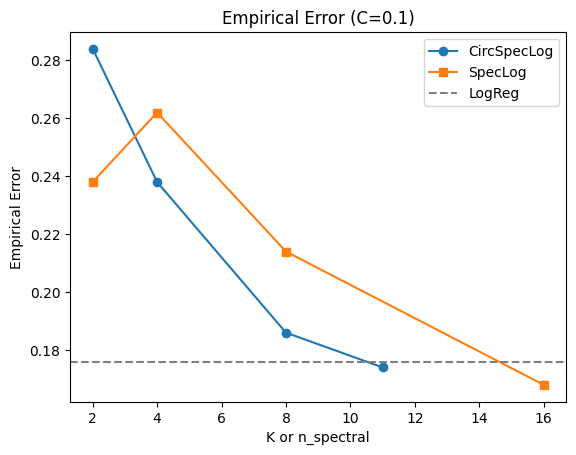

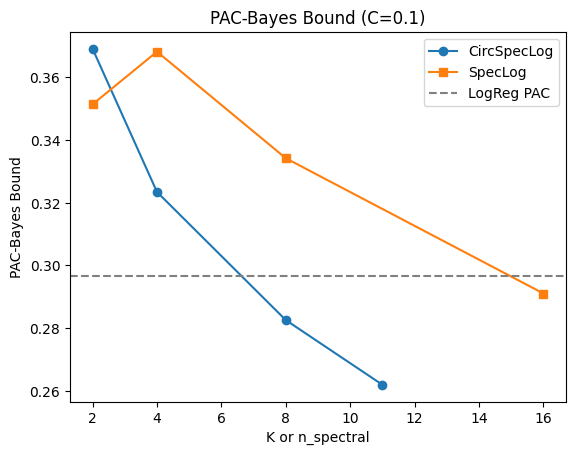

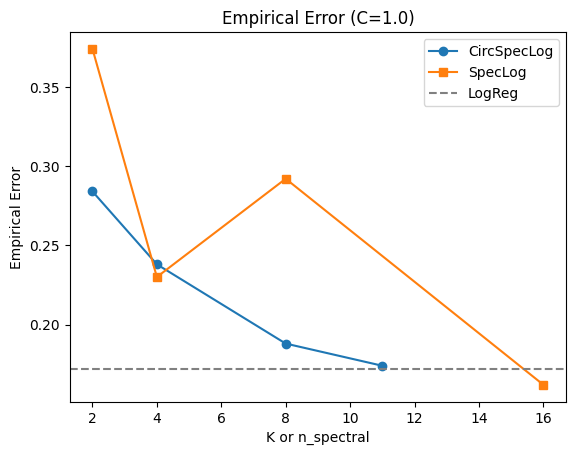

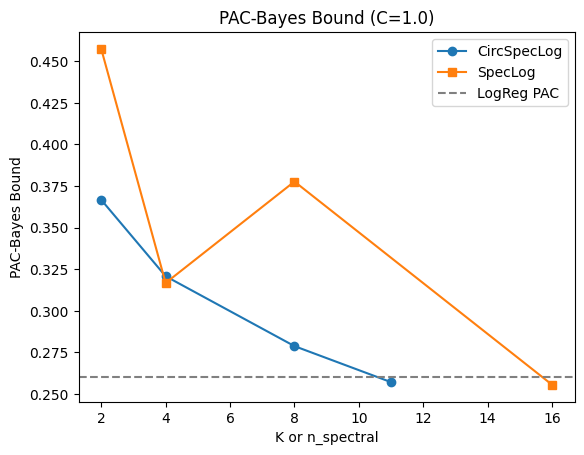

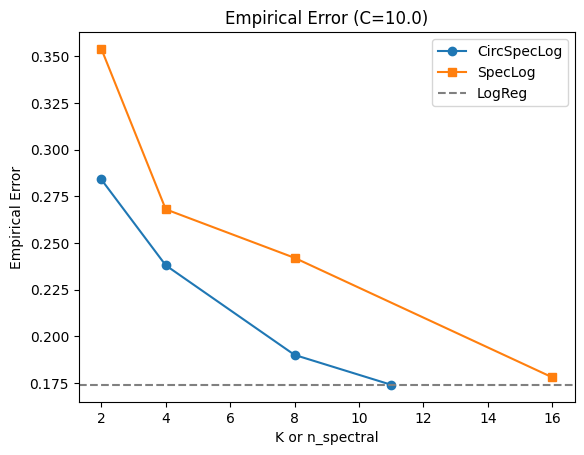

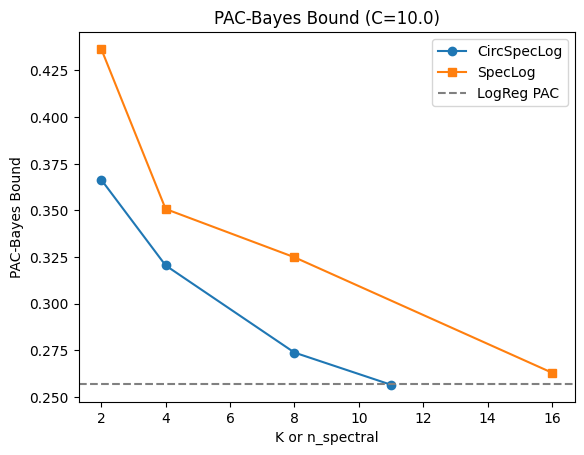

In [23]:
import matplotlib.pyplot as plt
# Generate data
X, y = make_classification(n_samples=500, n_features=20, random_state=0)
y_bin = 2 * y - 1
n = len(y_bin)

# Hyperparameter grids
C_values = [0.1, 1.0, 10.0]
K_values = [2, 4, 8, 11]  # up to full k_half = 20//2+1 = 11
n_spec_values = [2, 4, 8, 16]  # spectral dims, up to D=20

# Precompute baseline metrics for ordinary logistic regression
baseline_err = {}
baseline_pac = {}
for C in C_values:
    base = LogisticRegression(penalty="l2", C=C, solver="lbfgs", max_iter=1000)
    base.fit(X, y_bin)
    err0 = zero_one_loss(y_bin, base.predict(X))
    w0 = base.coef_.ravel()
    lam0 = 1.0 / C
    kl0 = 0.5 * lam0 * np.dot(w0, w0)
    pac0 = err0 + np.sqrt((kl0 + np.log(2 * np.sqrt(n) / 0.05)) / (2 * n))
    baseline_err[C] = err0
    baseline_pac[C] = pac0

# Sweep and plot
for C in C_values:
    # collect arrays
    errs_circ, pac_circ = [], []
    errs_spec, pac_spec = [], []

    for K in K_values:
        # circulant spectral
        circ = SpectralCirculantLogisticRegression(C=C, K=K)
        circ.fit(X, y_bin)
        e = zero_one_loss(y_bin, circ.predict(X))
        F = np.concatenate([circ.F_real_, circ.F_imag_])
        lam = 1.0 / C
        kl = 0.5 * lam * np.dot(F, F)
        p = e + np.sqrt((kl + np.log(2 * np.sqrt(n) / 0.05)) / (2 * n))
        errs_circ.append(e)
        pac_circ.append(p)

    for d in n_spec_values:
        # fixed-basis spectral
        spec = SpectralLogisticRegression(C=C, n_spectral=d)
        spec.fit(X, y_bin)
        e = zero_one_loss(y_bin, spec.predict(X))
        w = spec.coef_.ravel()
        lam = 1.0 / C
        kl = 0.5 * lam * np.dot(w, w)
        p = e + np.sqrt((kl + np.log(2 * np.sqrt(n) / 0.05)) / (2 * n))
        errs_spec.append(e)
        pac_spec.append(p)

    # Plot empirical error
    plt.figure()
    plt.plot(K_values, errs_circ, marker='o', label='CircSpecLog')
    plt.plot(n_spec_values, errs_spec, marker='s', label='SpecLog')
    plt.axhline(baseline_err[C], linestyle='--', color='grey', label='LogReg')
    plt.xlabel('K or n_spectral')
    plt.ylabel('Empirical Error')
    plt.title(f'Empirical Error (C={C})')
    plt.legend()
    plt.show()

    # Plot PAC-Bayes bound
    plt.figure()
    plt.plot(K_values, pac_circ, marker='o', label='CircSpecLog')
    plt.plot(n_spec_values, pac_spec, marker='s', label='SpecLog')
    plt.axhline(baseline_pac[C], linestyle='--', color='grey', label='LogReg PAC')
    plt.xlabel('K or n_spectral')
    plt.ylabel('PAC-Bayes Bound')
    plt.title(f'PAC-Bayes Bound (C={C})')
    plt.legend()
    plt.show()